In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchsummary import summary
from torchvision import models
from tqdm import tqdm
import os
import cv2
import optuna 
import numpy as np
from matplotlib import pyplot as plt
import glob
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import time
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights , resnet50, ResNet50_Weights

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu
PyTorch version: 2.4.1+cu121
CUDA available: False


In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
# Data directory
# data_dir = './asl_dataset_full'
data_dir='data/asl_dataset'

# Show available classes
print(os.listdir(data_dir))

['f', 'z', 'h', 'v', 'l', '1', '9', '6', 'n', 'e', 'j', 'u', '2', 'p', 'q', '3', 't', 'o', '0', '5', '7', 'y', 'w', 'x', 'a', 'i', 'c', 'd', 'b', 'k', '8', '4', 'r', 's', 'g', 'm']


In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# Count images per class
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    image_files = glob.glob(os.path.join(folder_path, '*.jpeg'))
    num_images = len(image_files)
    print(f'{folder}: {num_images} images')

f: 70 images
z: 70 images
h: 70 images
v: 70 images
l: 70 images
1: 70 images
9: 70 images
6: 70 images
n: 70 images
e: 70 images
j: 70 images
u: 70 images
2: 70 images
p: 70 images
q: 70 images
3: 70 images
t: 65 images
o: 70 images
0: 70 images
5: 70 images
7: 70 images
y: 70 images
w: 70 images
x: 70 images
a: 70 images
i: 70 images
c: 70 images
d: 70 images
b: 70 images
k: 70 images
8: 70 images
4: 70 images
r: 70 images
s: 70 images
g: 70 images
m: 70 images


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
class_counts = {}
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images

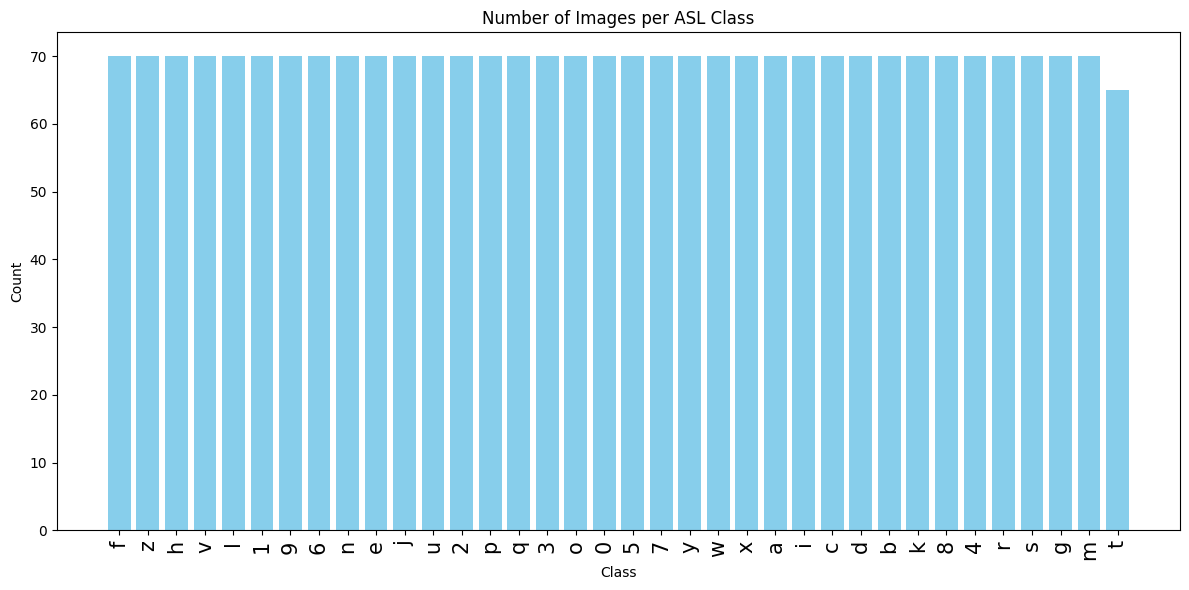

Total images: 2515
Number of classes: 36
Min images per class: 65
Max images per class: 70
Average images per class: 69.9


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(12, 6))
plt.bar(sorted_counts.keys(), sorted_counts.values(), color='skyblue')
plt.title('Number of Images per ASL Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=90, fontsize=15)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300)
plt.show()

print(f"Total images: {sum(class_counts.values())}")
print(f"Number of classes: {len(class_counts)}")
print(f"Min images per class: {min(class_counts.values())}")
print(f"Max images per class: {max(class_counts.values())}")
print(f"Average images per class: {np.mean(list(class_counts.values())):.1f}")

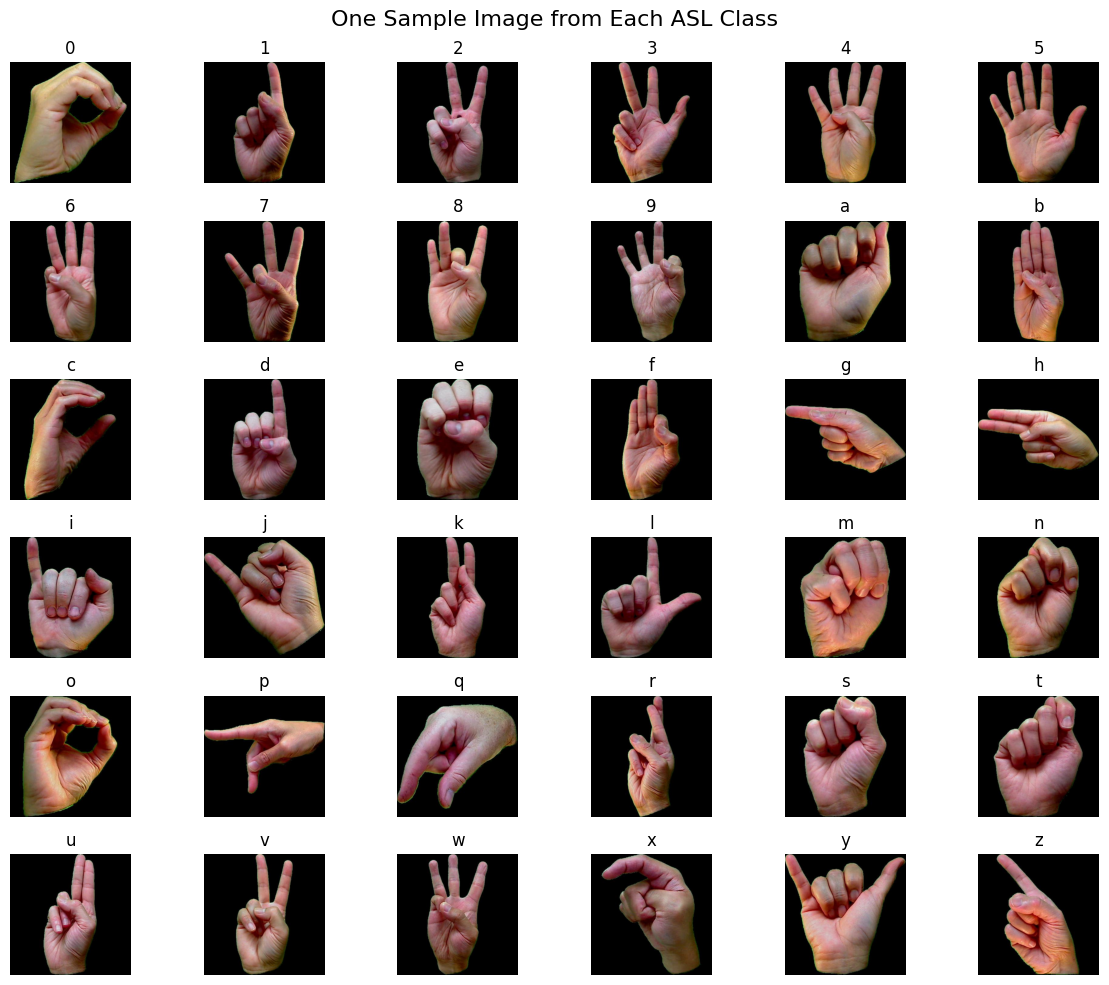

In [6]:
# --- [CELL 5]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
# === BEFORE (original) ===
# import random
# num_samples = 36  # one per class
# fig, axes = plt.subplots(3, 3, figsize=(7, 6))
# axes = axes.ravel()
# 
# for i, class_name in enumerate(sorted(class_counts.keys())):
#     class_path = os.path.join(data_dir, class_name)
#     img_files = [f for f in os.listdir(class_path) if f.endswith(('.jpeg'))]
#     if img_files:
#         img_path = os.path.join(class_path, random.choice(img_files))
#         img = cv2.imread(img_path)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         axes[i].imshow(img)
#         axes[i].set_title(class_name, fontsize=12)
#     axes[i].axis('off')
# 
# plt.suptitle('One Sample Image from Each ASL Class', fontsize=16)
# plt.tight_layout()
# plt.savefig('sample_images_per_class.png', dpi=300)
# plt.show()

# === AFTER (edited) ===
import random
num_samples = 36
fig, axes = plt.subplots(6, 6, figsize=(12, 10))
axes = axes.ravel()

for i, class_name in enumerate(sorted(class_counts.keys())):
    class_path = os.path.join(data_dir, class_name)
    img_files = [f for f in os.listdir(class_path) if f.endswith('.jpeg')]
    if img_files:
        img_path = os.path.join(class_path, random.choice(img_files))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(class_name, fontsize=12)
    axes[i].axis('off')

plt.suptitle('One Sample Image from Each ASL Class', fontsize=16)
plt.tight_layout()
plt.savefig('sample_images_per_class.png', dpi=300)
plt.show()

In [7]:
import os

assert 'axes' in globals(), "Expected axes from previous plotting cell"
assert 'class_counts' in globals(), "Expected class_counts from previous plotting cell"

axes_arr = list(axes)
expected_classes = sorted(class_counts.keys())

assert len(axes_arr) >= len(expected_classes), (
    f"Expected at least {len(expected_classes)} axes, got {len(axes_arr)}"
)

for i, class_name in enumerate(expected_classes):
    assert class_name in axes_arr[i].get_title(), (
        f"Axis {i} does not appear to plot class {class_name}"
    )

assert os.path.exists('sample_images_per_class.png'), "Expected output image to be saved"
assert os.path.getsize('sample_images_per_class.png') > 0, "Saved output image is empty"